# Load Training Data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

df = pd.read_csv('train.csv')
df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12,target
0,RGR-59098732,8791,2100.75549,477.599884,L01,3063.50851,4012.79629,4199.71112,L01,4107.38244,1208.06182,507.389416,1053.05055,1183
1,RGR-50849885,8450,2102.66874,394.439384,L01,3080.13369,4012.79629,4199.71112,L01,4060.92487,1205.53931,507.389416,1375.74344,95
2,RGR-16537509,8043,2101.36773,381.308779,L03,3096.75887,4012.79629,4199.71112,L01,4019.55854,1203.37182,507.389416,1375.74344,112
3,RGR-83467838,10386,2100.67896,381.308779,L00,3059.35221,4012.79629,4199.71112,L01,4115.01930,1208.43552,507.389416,1375.74344,949
4,RGR-72396047,7702,2102.05650,464.469279,L03,3080.13369,4012.79629,4199.71112,L01,4015.74011,1202.62440,507.389416,1375.74344,251


# EDA (Exploratry Data Analysis)

In [2]:
# Check the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5757 entries, 0 to 5756
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      5757 non-null   object 
 1   f01     5757 non-null   int64  
 2   f02     5757 non-null   float64
 3   f03     5757 non-null   float64
 4   f04     5757 non-null   object 
 5   f05     5757 non-null   float64
 6   f06     5757 non-null   float64
 7   f07     5757 non-null   float64
 8   f08     5757 non-null   object 
 9   f09     5757 non-null   float64
 10  f10     5757 non-null   float64
 11  f11     5757 non-null   float64
 12  f12     5757 non-null   float64
 13  target  5757 non-null   int64  
dtypes: float64(9), int64(2), object(3)
memory usage: 629.8+ KB


In [3]:
# check for null values and duplicates
print(df.isnull().sum())
print("Number of duplicate rows:", df.duplicated().sum())

id        0
f01       0
f02       0
f03       0
f04       0
f05       0
f06       0
f07       0
f08       0
f09       0
f10       0
f11       0
f12       0
target    0
dtype: int64
Number of duplicate rows: 0


In [4]:
# check the statistical summary of the dataframe
df.describe()

,f01,f02,f03,f05,f06,f07,f09,f10,f11,f12,target
count,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000,5757.000000
mean,9223.527184,2101.073960,431.625660,3050.612947,4012.860216,4199.672186,4094.796661,1207.085695,507.385140,1220.752288,728.996179
std,1144.350882,0.790656,30.254563,42.687497,0.474594,0.059258,42.084254,2.245902,0.024605,166.705625,637.202589
min,7251.000000,2099.760600,381.308779,2967.913730,4012.796290,4199.470010,3984.238060,1201.335120,506.896495,837.102935,2.000000
25%,8230.000000,2100.449370,407.569990,3017.789260,4012.796290,4199.647420,4066.334310,1205.315080,507.389416,1086.357260,218.000000
50%,9231.000000,2100.908550,429.454331,3053.117770,4012.796290,4199.710430,4097.199960,1207.220980,507.389416,1293.295680,545.000000
75%,10188.000000,2101.520790,455.715542,3084.289980,4012.796290,4199.711120,4130.611220,1208.902650,507.389416,1375.743440,1077.000000
max,11255.000000,2105.347280,481.976752,3171.572170,4024.991990,4199.711120,4168.159120,1211.948350,507.389416,1375.743440,3556.000000


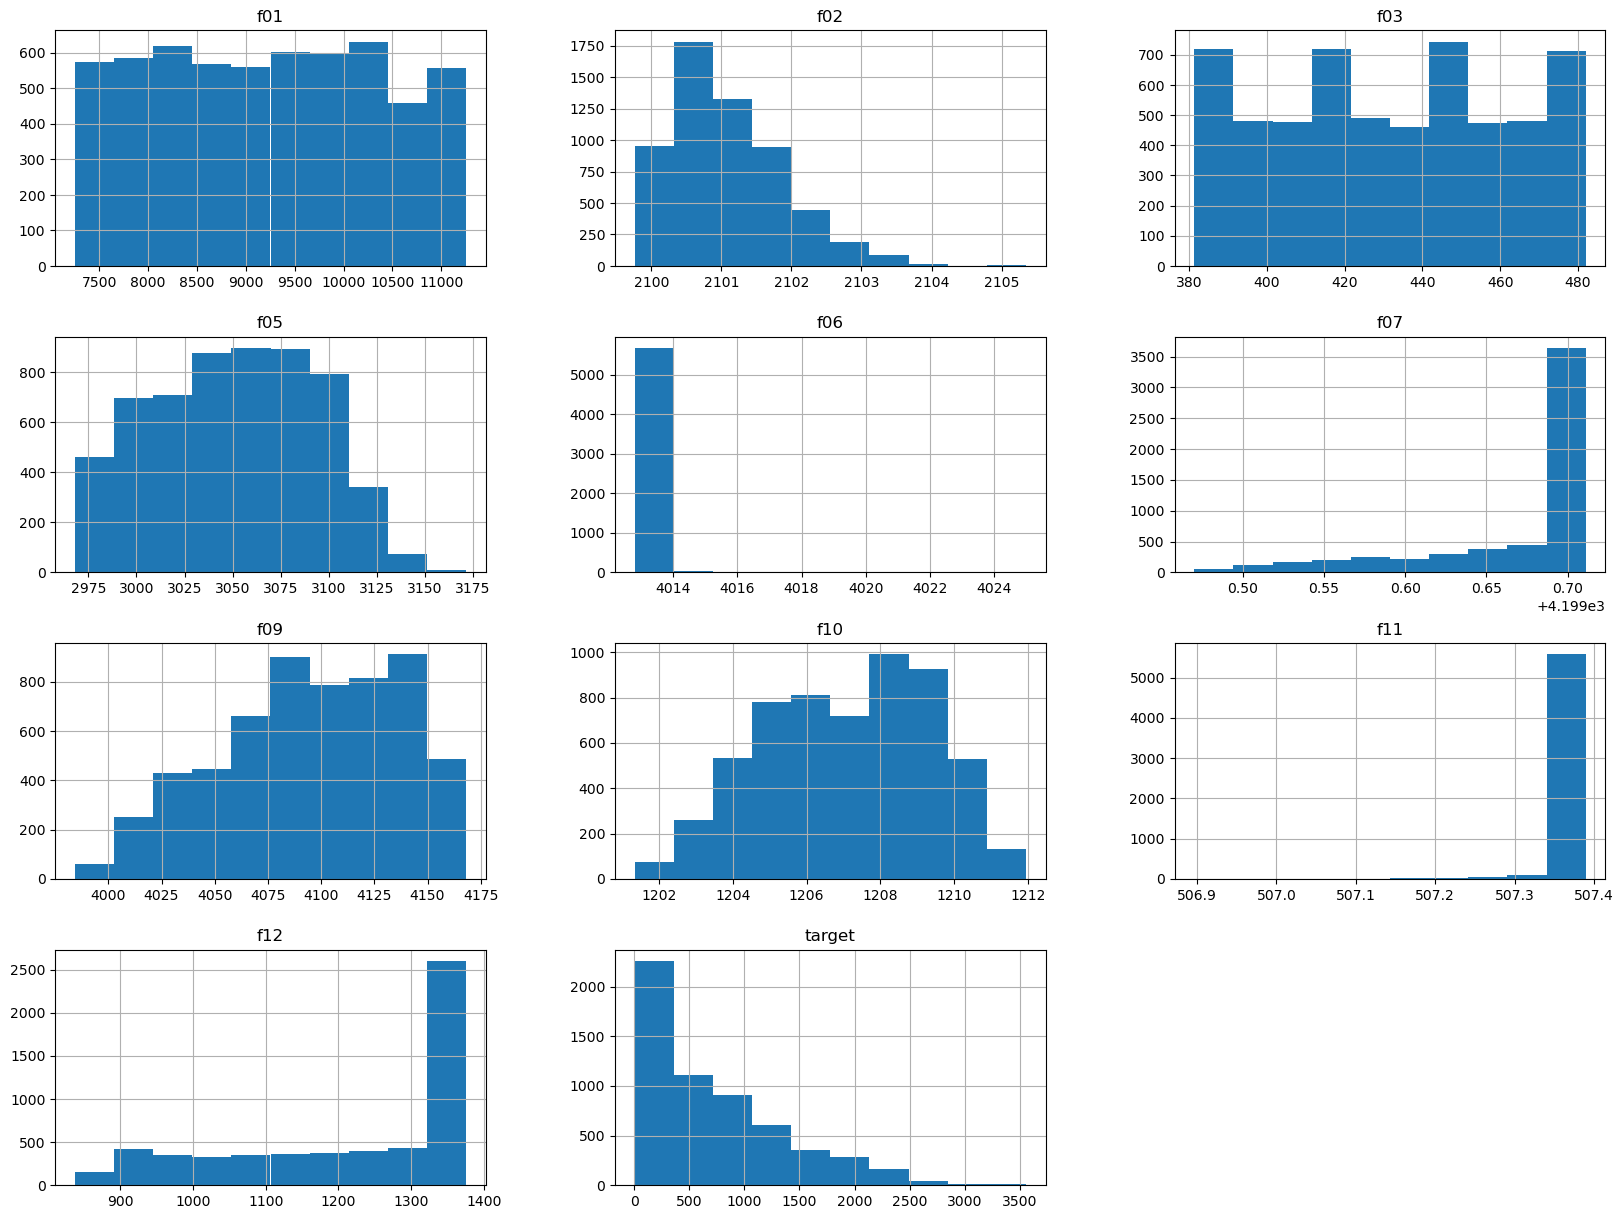

In [5]:
# Visualize the distribution of all numerical features using histograms
df.hist(figsize=(20, 15))
plt.title('Histograms of All Features')
plt.show()

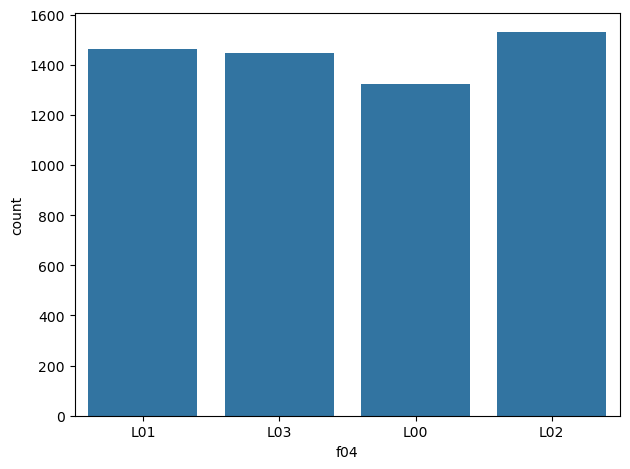

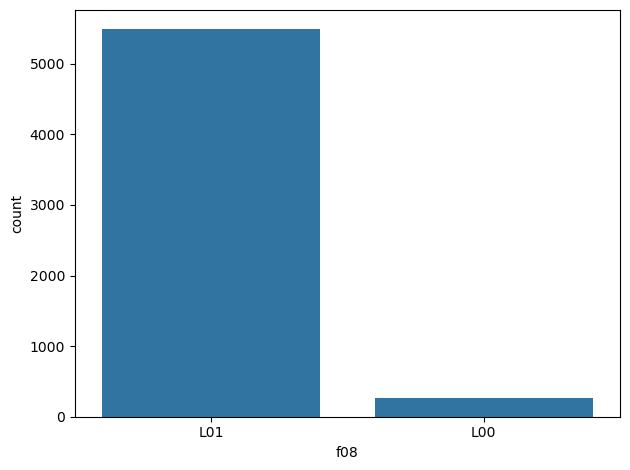

In [6]:
# Visualize the distribution of all categorical features using count plots
catg_cols = df.select_dtypes(include=object).columns.to_list()
for col in catg_cols:
    if col != "id":
        sns.countplot(df , x = col)
        plt.tight_layout()
        plt.show()

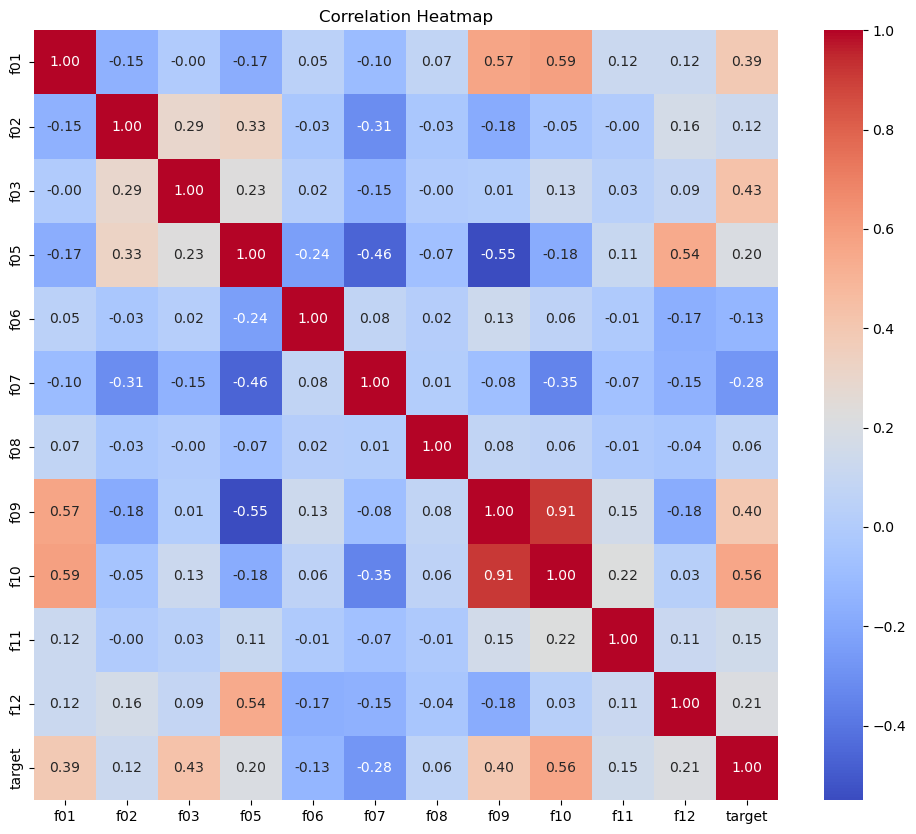

In [16]:
# check the correlation and collinearity between features in the dataset

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# Encoding for Categorical Features


In [2]:
from sklearn.preprocessing import OneHotEncoder , LabelEncoder
one_hot = OneHotEncoder(sparse_output=False , drop="first")
label = LabelEncoder()

df['f08'] = label.fit_transform(df[['f08']])
encoded = one_hot.fit_transform(df[['f04']])
encoded_df = pd.DataFrame(encoded , columns=one_hot.get_feature_names_out(['f04']))
df_encoded = pd.concat([df , encoded_df] , axis=1).drop("f04" , axis = 1)

df_encoded


c:\Users\AHMED ELFATATRY\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,id,f01,f02,f03,f05,f06,f07,f08,f09,f10,f11,f12,target,f04_L01,f04_L02,f04_L03
0,RGR-59098732,8791,2100.75549,477.599884,3063.50851,4012.79629,4199.71112,1,4107.38244,1208.06182,507.389416,1053.05055,1183,1.0,0.0,0.0
1,RGR-50849885,8450,2102.66874,394.439384,3080.13369,4012.79629,4199.71112,1,4060.92487,1205.53931,507.389416,1375.74344,95,1.0,0.0,0.0
2,RGR-16537509,8043,2101.36773,381.308779,3096.75887,4012.79629,4199.71112,1,4019.55854,1203.37182,507.389416,1375.74344,112,0.0,0.0,1.0
3,RGR-83467838,10386,2100.67896,381.308779,3059.35221,4012.79629,4199.71112,1,4115.01930,1208.43552,507.389416,1375.74344,949,0.0,0.0,0.0
4,RGR-72396047,7702,2102.05650,464.469279,3080.13369,4012.79629,4199.71112,1,4015.74011,1202.62440,507.389416,1375.74344,251,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5752,RGR-67617907,10474,2101.67385,460.092410,3011.55482,4012.79629,4199.70564,1,4129.02021,1208.22998,507.389416,1375.74344,1786,0.0,0.0,0.0
5753,RGR-32441805,8164,2099.99019,398.816253,3051.03962,4012.79629,4199.71112,1,4051.37879,1204.21265,507.389416,1375.74344,66,0.0,0.0,1.0
5754,RGR-85168335,8648,2102.13303,481.976752,3090.52442,4012.79629,4199.71112,1,4051.37879,1205.24034,507.389416,1375.74344,368,1.0,0.0,0.0
5755,RGR-84131733,9143,2100.21978,403.193121,3171.57217,4012.79629,4199.71112,0,4115.33750,1207.59469,507.389416,1269.27117,182,1.0,0.0,0.0


In [8]:
# Check the info of the encoded dataframe
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5757 entries, 0 to 5756
Data columns (total 16 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       5757 non-null   object 
 1   f01      5757 non-null   int64  
 2   f02      5757 non-null   float64
 3   f03      5757 non-null   float64
 4   f05      5757 non-null   float64
 5   f06      5757 non-null   float64
 6   f07      5757 non-null   float64
 7   f08      5757 non-null   int64  
 8   f09      5757 non-null   float64
 9   f10      5757 non-null   float64
 10  f11      5757 non-null   float64
 11  f12      5757 non-null   float64
 12  target   5757 non-null   int64  
 13  f04_L01  5757 non-null   float64
 14  f04_L02  5757 non-null   float64
 15  f04_L03  5757 non-null   float64
dtypes: float64(12), int64(3), object(1)
memory usage: 719.8+ KB


# Spliting

In [3]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop(['id' , 'target'] , axis=1)
y = df_encoded['target']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("Training target size:", y_train.shape)
print("Testing target size:", y_test.shape)

Training set size: (4605, 14)
Testing set size: (1152, 14)
Training target size: (4605,)
Testing target size: (1152,)


# LinearRegression --> Base Model

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

lin_preds = lin_reg.predict(X_test)
lin_rmse = np.sqrt(mean_squared_error(y_test, lin_preds))
print("Linear Regression RMSE:", lin_rmse)



Linear Regression RMSE: 429.32290212001266


# Perform cross-validation with KFold


In [ ]:
# perform cross-validation with LightGBM
from sklearn.model_selection import KFold
from lightgbm import LGBMRegressor, early_stopping, log_evaluation

X = df_encoded.drop(['id', 'target'], axis=1)
y = df_encoded['target']

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_va = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_va = y.iloc[train_idx], y.iloc[val_idx]
    
    lgb_model = LGBMRegressor(
        n_estimators=2000,
        learning_rate=0.05,
        num_leaves=64,
        max_depth=-1,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=1.0,
        random_state=42,
        n_jobs=-1
    )
    
    lgb_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[early_stopping(50), log_evaluation(50)],
        
    )
    
    val_preds = lgb_model.predict(X_va)
    rmse = np.sqrt(mean_squared_error(y_va, val_preds))
    rmse_scores.append(rmse)
    
    print(f"Fold {fold+1} RMSE: {rmse:.4f}")

print("Average CV RMSE:", np.mean(rmse_scores))


C:\Users\AHMED ELFATATRY\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001516 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1424
[LightGBM] [Info] Number of data points in the train set: 4605, number of used features: 14
[LightGBM] [Info] Start training from score 732.696200
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 227.799	valid_0's l2: 51892.5
[100]	valid_0's rmse: 215.136	valid_0's l2: 46283.6
[150]	valid_0's rmse: 211.942	valid_0's l2: 44919.5
[200]	valid_0's rmse: 211.248	valid_0's l2: 44625.9
[250]	valid_0's rmse: 211.079	valid_0's l2: 44554.5
Early stopping, best iteration is:
[223]	valid_0's rmse: 211.074	valid_0's l2: 44552.2
Fold 1 RMSE: 211.0739
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000906 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1429
[LightGBM] [Info] Number of data

C:\Users\AHMED ELFATATRY\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's rmse: 242.463	valid_0's l2: 58788.3
[100]	valid_0's rmse: 227.714	valid_0's l2: 51853.6
[150]	valid_0's rmse: 223.889	valid_0's l2: 50126.2
[200]	valid_0's rmse: 223.149	valid_0's l2: 49795.4
[250]	valid_0's rmse: 222.838	valid_0's l2: 49656.7
[300]	valid_0's rmse: 222.633	valid_0's l2: 49565.6
[350]	valid_0's rmse: 222.923	valid_0's l2: 49694.6
Early stopping, best iteration is:
[317]	valid_0's rmse: 222.506	valid_0's l2: 49508.7
Fold 2 RMSE: 222.5055
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001055 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1421
[LightGBM] [Info] Number of data points in the train set: 4606, number of used features: 14
[LightGBM] [Info] Start training from score 725.052540
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 228.751	valid_0's l2: 52327.2


C:\Users\AHMED ELFATATRY\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's rmse: 207.385	valid_0's l2: 43008.5
[150]	valid_0's rmse: 204.645	valid_0's l2: 41879.7
[200]	valid_0's rmse: 203.758	valid_0's l2: 41517.3
[250]	valid_0's rmse: 203.716	valid_0's l2: 41500
Early stopping, best iteration is:
[208]	valid_0's rmse: 203.494	valid_0's l2: 41410
Fold 3 RMSE: 203.4944
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001074 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1431
[LightGBM] [Info] Number of data points in the train set: 4606, number of used features: 14
[LightGBM] [Info] Start training from score 722.187581
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 240.811	valid_0's l2: 57990


C:\Users\AHMED ELFATATRY\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[100]	valid_0's rmse: 221.245	valid_0's l2: 48949.3
[150]	valid_0's rmse: 216.932	valid_0's l2: 47059.6
[200]	valid_0's rmse: 216.63	valid_0's l2: 46928.7
[250]	valid_0's rmse: 215.846	valid_0's l2: 46589.7
[300]	valid_0's rmse: 216.073	valid_0's l2: 46687.7
Early stopping, best iteration is:
[250]	valid_0's rmse: 215.846	valid_0's l2: 46589.7
Fold 4 RMSE: 215.8464
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1420
[LightGBM] [Info] Number of data points in the train set: 4606, number of used features: 14
[LightGBM] [Info] Start training from score 736.503908
Training until validation scores don't improve for 50 rounds


C:\Users\AHMED ELFATATRY\AppData\Roaming\Python\Python313\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[50]	valid_0's rmse: 226.052	valid_0's l2: 51099.3
[100]	valid_0's rmse: 207.276	valid_0's l2: 42963.3
[150]	valid_0's rmse: 205.056	valid_0's l2: 42047.8
[200]	valid_0's rmse: 204.241	valid_0's l2: 41714.3
[250]	valid_0's rmse: 203.441	valid_0's l2: 41388.2
Early stopping, best iteration is:
[248]	valid_0's rmse: 203.433	valid_0's l2: 41384.9
Fold 5 RMSE: 203.4328
Average CV RMSE: 211.27060520111323


# Polynomial Model

In [12]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=4, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_val_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

poly_preds = poly_reg.predict(X_val_poly)
poly_rmse = np.sqrt(mean_squared_error(y_test, poly_preds))
print("Polynomial Regression (deg=4) RMSE:", poly_rmse)

Polynomial Regression (deg=4) RMSE: 383.32711536756625


# RandomForest Model

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=180,      
    max_depth=20,          
    min_samples_split=2,   
    min_samples_leaf=1,
    bootstrap=True,    
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 219.5372121430468


# xgboost Model

In [15]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=10,
    min_child_weight=5,
    subsample=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

test_preds = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test_preds))
print("XGBoost RMSE:", rmse)


XGBoost RMSE: 210.58501104067213


# catboost Model

In [6]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.05,
    depth=10,
    l2_leaf_reg=2,
    subsample=0.8,
    random_seed=42,
    verbose=False
)

cat_model.fit(X_train, y_train)

test_preds = cat_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, test_preds))
print("CatBoost RMSE:", rmse)


CatBoost RMSE: 197.3870870948861


# lightgbm Model

In [17]:
from lightgbm import LGBMRegressor

lgb_model = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=10,
    max_depth=-1,
    min_child_samples=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lgb_model.fit(X_train, y_train)

test_preds = lgb_model.predict(X_test)


rmse = np.sqrt(mean_squared_error(y_test, test_preds))
print("LightGBM RMSE:", rmse)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001570 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1424
[LightGBM] [Info] Number of data points in the train set: 4605, number of used features: 14
[LightGBM] [Info] Start training from score 732.696200
LightGBM RMSE: 205.24912273691385


# Load Test Data

In [7]:
test_df = pd.read_csv('test.csv')
test_df.head()

,id,f01,f02,f03,f04,f05,f06,f07,f08,f09,f10,f11,f12
0,RGE-73622541,11013,2100.83202,451.338673,L00,2972.07002,4012.79629,4199.70975,L01,4116.61031,1206.84727,507.389416,989.986201
1,RGE-52769114,9572,2100.14325,460.092410,L02,3007.39853,4013.00300,4199.66660,L01,4156.38563,1209.79955,507.389416,1167.439990
2,RGE-40164553,9121,2100.83202,425.077463,L01,3094.68072,4012.79629,4199.64673,L01,4088.29028,1207.83759,507.389416,1375.743440
3,RGE-73877551,7647,2100.98508,381.308779,L03,3063.50851,4012.79629,4199.71112,L01,4041.19631,1203.85763,507.389416,1170.170050
4,RGE-14598387,7746,2100.37284,455.715542,L03,3088.44628,4012.79629,4199.69536,L01,4062.19768,1205.87564,507.389416,1049.228470


# Encode Categorical Features

In [8]:
# take a copy of the test ids for submission
test_ids = test_df["id"].copy()


# encode the test data
test_df['f08'] = label.transform(test_df[['f08']])
test_encoded = one_hot.transform(test_df[['f04']])
test_encoded_df = pd.DataFrame(test_encoded, columns=one_hot.get_feature_names_out(['f04']))
test_df_encoded = pd.concat([test_df.reset_index(drop=True), test_encoded_df], axis=1).drop("f04", axis=1)
test_df_encoded.head()

c:\Users\AHMED ELFATATRY\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


,id,f01,f02,f03,f05,f06,f07,f08,f09,f10,f11,f12,f04_L01,f04_L02,f04_L03
0,RGE-73622541,11013,2100.83202,451.338673,2972.07002,4012.79629,4199.70975,1,4116.61031,1206.84727,507.389416,989.986201,0.0,0.0,0.0
1,RGE-52769114,9572,2100.14325,460.092410,3007.39853,4013.00300,4199.66660,1,4156.38563,1209.79955,507.389416,1167.439990,0.0,1.0,0.0
2,RGE-40164553,9121,2100.83202,425.077463,3094.68072,4012.79629,4199.64673,1,4088.29028,1207.83759,507.389416,1375.743440,1.0,0.0,0.0
3,RGE-73877551,7647,2100.98508,381.308779,3063.50851,4012.79629,4199.71112,1,4041.19631,1203.85763,507.389416,1170.170050,0.0,0.0,1.0
4,RGE-14598387,7746,2100.37284,455.715542,3088.44628,4012.79629,4199.69536,1,4062.19768,1205.87564,507.389416,1049.228470,0.0,0.0,1.0


# Submission

In [9]:
# prepare the final test set for prediction
X_final_test = test_df_encoded.drop(["id"], axis=1)
X_final_test = X_final_test[X.columns]

In [10]:
# predict probabilities for the test set
cat_preds = cat_model.predict(X_final_test)

In [11]:
# create a submission dataframe for CatBoost predictions
submission_cat = pd.DataFrame({
    "id": test_ids,
    "target": cat_preds
})

In [12]:
# save the submission dataframe to a CSV file
submission_cat.to_csv("Cat_Submission.csv", index=False)

# Save Best Model 

In [31]:
# save the best model to a file for future use
import joblib
joblib.dump(cat_model, "cat_model.pkl")

['cat_model.pkl']